In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Resolve the repository root whether this notebook is run from the repo root or notebooks/.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
df = pd.read_csv(RAW_DIR / "transfers.csv")


In [4]:
df.shape

(70006, 23)

In [5]:
df.head()

,league,season,window,team_id,team_name,team_country,dir,player_id,player_name,player_age,player_nation,player_nation2,player_pos,counter_team_id,counter_team_name,counter_team_country,transfer_fee_amnt,market_val_amnt,is_free,is_loan,is_loan_end,is_retired,transfer_id
0,GB1,2009,s,985,Manchester United,England,in,33544,Antonio Valencia,23.0,Ecuador,NaN,RB,1071,Wigan Athletic,England,18800000.0,NaN,False,False,False,False,310832
1,GB1,2009,s,985,Manchester United,England,in,62049,Mame Diouf,21.0,Senegal,NaN,CF,687,Molde FK,Norway,4500000.0,1600000.0,False,False,False,False,319841
2,GB1,2009,s,985,Manchester United,England,in,43261,Gabriel Obertan,20.0,France,Guadeloupe,AM,40,FC Girondins Bordeaux,France,4000000.0,400000.0,False,False,False,False,315185
3,GB1,2009,s,985,Manchester United,England,in,1397,Michael Owen,29.0,England,NaN,CF,762,Newcastle United,England,0.0,NaN,True,False,False,False,306421
4,GB1,2009,s,985,Manchester United,England,in,73538,Scott Moffatt,18.0,England,NaN,CB,5242,Manchester United U18,England,NaN,NaN,False,False,False,False,339015


In [6]:
df.columns.tolist()

['league',
 'season',
 'window',
 'team_id',
 'team_name',
 'team_country',
 'dir',
 'player_id',
 'player_name',
 'player_age',
 'player_nation',
 'player_nation2',
 'player_pos',
 'counter_team_id',
 'counter_team_name',
 'counter_team_country',
 'transfer_fee_amnt',
 'market_val_amnt',
 'is_free',
 'is_loan',
 'is_loan_end',
 'is_retired',
 'transfer_id']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70006 entries, 0 to 70005
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   league                70006 non-null  object 
 1   season                70006 non-null  int64  
 2   window                70006 non-null  object 
 3   team_id               70006 non-null  int64  
 4   team_name             70006 non-null  object 
 5   team_country          70006 non-null  object 
 6   dir                   70006 non-null  object 
 7   player_id             70006 non-null  int64  
 8   player_name           70006 non-null  object 
 9   player_age            69990 non-null  float64
 10  player_nation         70001 non-null  object 
 11  player_nation2        23181 non-null  object 
 12  player_pos            70006 non-null  object 
 13  counter_team_id       70006 non-null  object 
 14  counter_team_name     70006 non-null  object 
 15  counter_team_countr

In [8]:
df["season"].min(), df["season"].max()

(2009, 2021)

In [9]:
df["season"].value_counts().sort_index()

season
2009    4931
2010    5170
2011    5504
2012    5399
2013    5654
2014    5868
2015    5777
2016    5620
2017    5618
2018    5572
2019    5725
2020    5140
2021    4028
Name: count, dtype: int64

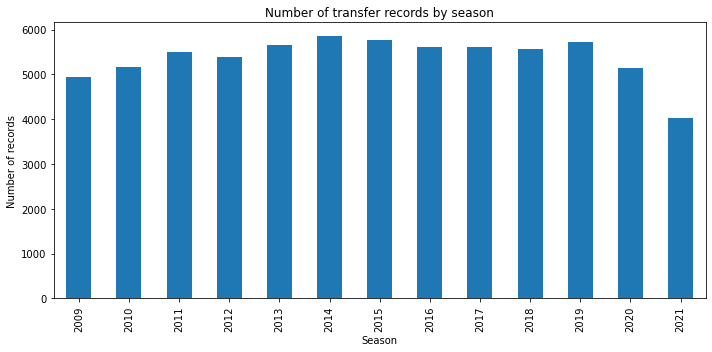

In [10]:
plt.figure(figsize=(10, 5))
df["season"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of transfer records by season")
plt.xlabel("Season")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

In [11]:
df["league"].value_counts()

league
IT1    16135
PO1    11378
GB1    11161
ES1     8704
FR1     8199
NL1     7429
L1      7000
Name: count, dtype: int64

In [12]:
league_map = {
    "GB1": "Premier League",
    "ES1": "La Liga",
    "IT1": "Serie A",
    "L1": "Bundesliga",
    "FR1": "Ligue 1",
    "NL1": "Eredivisie",
    "PO1": "Primeira Liga"
}

df["league_name"] = df["league"].map(league_map)

In [13]:
df[["league", "league_name"]].drop_duplicates().sort_values("league")

,league,league_name
11161,ES1,La Liga
43000,FR1,Ligue 1
0,GB1,Premier League
19865,IT1,Serie A
36000,L1,Bundesliga
62577,NL1,Eredivisie
51199,PO1,Primeira Liga


In [14]:
df["league_name"].value_counts()

league_name
Serie A           16135
Primeira Liga     11378
Premier League    11161
La Liga            8704
Ligue 1            8199
Eredivisie         7429
Bundesliga         7000
Name: count, dtype: int64

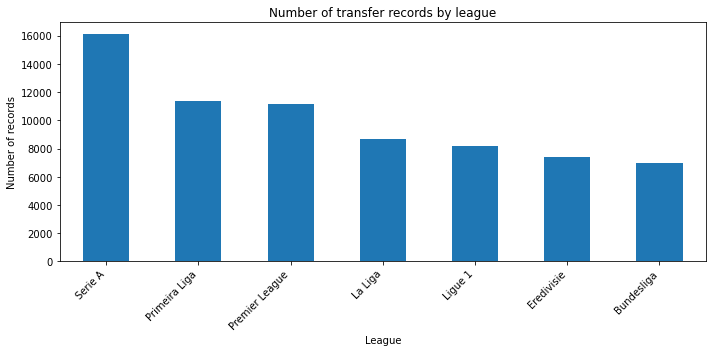

In [15]:
plt.figure(figsize=(10, 5))
df["league_name"].value_counts().plot(kind="bar")
plt.title("Number of transfer records by league")
plt.xlabel("League")
plt.ylabel("Number of records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [16]:
df["dir"].value_counts()

dir
left    38072
in      31934
Name: count, dtype: int64

In [17]:
missing = df.isna().sum().sort_values(ascending=False)
missing

player_nation2          46825
transfer_fee_amnt       41743
market_val_amnt         19264
player_age                 16
player_nation               5
league                      0
counter_team_name           0
transfer_id                 0
is_retired                  0
is_loan_end                 0
is_loan                     0
is_free                     0
counter_team_country        0
player_pos                  0
counter_team_id             0
season                      0
player_name                 0
player_id                   0
dir                         0
team_country                0
team_name                   0
team_id                     0
window                      0
league_name                 0
dtype: int64

In [18]:
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

missing_table

,missing_count,missing_percent
player_nation2,46825,66.887124
transfer_fee_amnt,41743,59.627746
market_val_amnt,19264,27.517641
player_age,16,0.022855
player_nation,5,0.007142
league,0,0.000000
counter_team_name,0,0.000000
transfer_id,0,0.000000
is_retired,0,0.000000
is_loan_end,0,0.000000


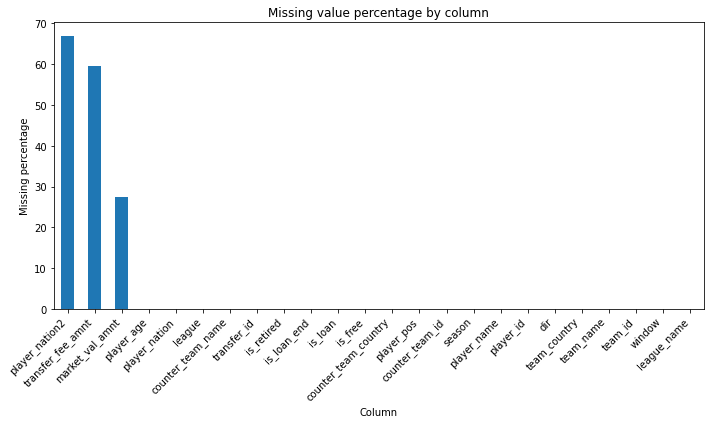

In [19]:
plt.figure(figsize=(10, 6))
missing_table["missing_percent"].plot(kind="bar")
plt.title("Missing value percentage by column")
plt.xlabel("Column")
plt.ylabel("Missing percentage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [20]:
df["transfer_fee_amnt"].describe()

count    2.826300e+04
mean     3.762225e+06
std      1.950388e+07
min      0.000000e+00
25%      0.000000e+00
50%      2.000000e+05
75%      2.500000e+06
max      5.500000e+08
Name: transfer_fee_amnt, dtype: float64

In [21]:
df[df["transfer_fee_amnt"].notna()]["transfer_fee_amnt"].describe()

count    2.826300e+04
mean     3.762225e+06
std      1.950388e+07
min      0.000000e+00
25%      0.000000e+00
50%      2.000000e+05
75%      2.500000e+06
max      5.500000e+08
Name: transfer_fee_amnt, dtype: float64

In [22]:
df.sort_values("transfer_fee_amnt", ascending=False).head(20)[
    [
        "season",
        "league_name",
        "team_name",
        "dir",
        "counter_team_name",
        "player_name",
        "player_pos",
        "transfer_fee_amnt",
        "is_free",
        "is_loan"
    ]
]

,season,league_name,team_name,dir,counter_team_name,player_name,player_pos,transfer_fee_amnt,is_free,is_loan
21001,2010,Serie A,Calcio Catania,left,Ascoli Calcio 1898,Simone Pesce,CM,550000000.0,False,False
22731,2011,Serie A,Genoa CFC,in,Piacenza FC,Davide Bertoncini,CB,550000000.0,False,False
20142,2009,Serie A,Parma FC,left,Ternana Calcio,Luca Tedeschi,CB,500000000.0,False,False
21045,2010,Serie A,AC Cesena,left,AC Bellaria Igea Marina,Caio De Cenco,CF,500000000.0,False,False
20719,2009,Serie A,US Palermo,left,Vicenza Calcio,Luca Di Matteo,LB,500000000.0,False,False
23793,2012,Serie A,Calcio Catania,left,AS Bari,Francesco Fedato,LW,500000000.0,False,False
22176,2011,Serie A,AC Cesena,left,Carrarese Calcio 1908,Sacha Cori,CF,500000000.0,False,False
20774,2009,Serie A,Genoa CFC,left,Vicenza Calcio,Danilo Russo,GK,500000000.0,False,False
22087,2011,Serie A,SSC Napoli,in,UC Sampdoria,Daniele Mannini,RM,500000000.0,False,False
24136,2012,Serie A,Delfino Pescara 1936,in,AC Pisa 1909,Luca Berardocco,DM,500000000.0,False,False


In [23]:
df["is_free"].value_counts(dropna=False)

is_free
False    57036
True     12970
Name: count, dtype: int64

In [24]:
df["is_loan"].value_counts(dropna=False)

is_loan
False    36587
True     33419
Name: count, dtype: int64

In [25]:
df["is_loan_end"].value_counts(dropna=False)

is_loan_end
False    56336
True     13670
Name: count, dtype: int64

In [26]:
def classify_transfer(row):
    if row["is_loan_end"]:
        return "Loan end"
    elif row["is_loan"]:
        return "Loan"
    elif row["is_free"]:
        return "Free transfer"
    else:
        return "Paid/undisclosed"

df["transfer_type"] = df.apply(classify_transfer, axis=1)

In [27]:
df["transfer_type"].value_counts()

transfer_type
Paid/undisclosed    23617
Loan                19749
Loan end            13670
Free transfer       12970
Name: count, dtype: int64

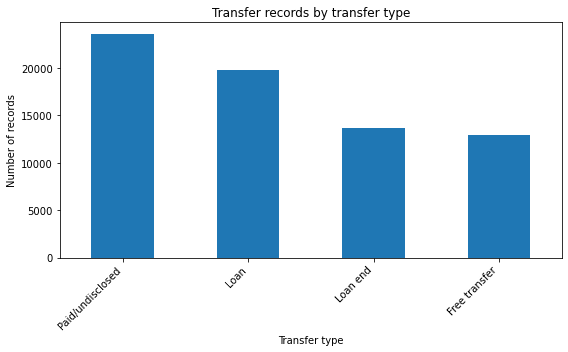

In [28]:
plt.figure(figsize=(8, 5))
df["transfer_type"].value_counts().plot(kind="bar")
plt.title("Transfer records by transfer type")
plt.xlabel("Transfer type")
plt.ylabel("Number of records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [29]:
def get_source_target(row):
    if row["dir"] == "in":
        source = row["counter_team_name"]
        target = row["team_name"]
        source_country = row["counter_team_country"]
        target_country = row["team_country"]
    elif row["dir"] == "left":
        source = row["team_name"]
        target = row["counter_team_name"]
        source_country = row["team_country"]
        target_country = row["counter_team_country"]
    else:
        source = np.nan
        target = np.nan
        source_country = np.nan
        target_country = np.nan
    
    return pd.Series({
        "source_club": source,
        "target_club": target,
        "source_country": source_country,
        "target_country": target_country
    })

direction_cols = df.apply(get_source_target, axis=1)
df = pd.concat([df, direction_cols], axis=1)

In [30]:
df[
    [
        "team_name",
        "dir",
        "counter_team_name",
        "source_club",
        "target_club",
        "player_name",
        "transfer_fee_amnt"
    ]
].head(20)

,team_name,dir,counter_team_name,source_club,target_club,player_name,transfer_fee_amnt
0,Manchester United,in,Wigan Athletic,Wigan Athletic,Manchester United,Antonio Valencia,18800000.0
1,Manchester United,in,Molde FK,Molde FK,Manchester United,Mame Diouf,4500000.0
2,Manchester United,in,FC Girondins Bordeaux,FC Girondins Bordeaux,Manchester United,Gabriel Obertan,4000000.0
3,Manchester United,in,Newcastle United,Newcastle United,Manchester United,Michael Owen,0.0
4,Manchester United,in,Manchester United U18,Manchester United U18,Manchester United,Scott Moffatt,NaN
5,Manchester United,in,Tottenham Hotspur,Tottenham Hotspur,Manchester United,Fraizer Campbell,NaN
6,Manchester United,in,Altrincham FC,Altrincham FC,Manchester United,Scott Moffatt,NaN
7,Manchester United,in,Plymouth Argyle,Plymouth Argyle,Manchester United,James Chester,NaN
8,Manchester United,in,Huddersfield Town,Huddersfield Town,Manchester United,Danny Drinkwater,NaN
9,Manchester United,in,Wycombe Wanderers,Wycombe Wanderers,Manchester United,Tom Heaton,NaN


In [31]:
df_clean = df.copy()

df_clean = df_clean.dropna(subset=["source_club", "target_club"])
df_clean = df_clean[df_clean["source_club"] != df_clean["target_club"]]

In [32]:
df.shape, df_clean.shape

((70006, 29), (70005, 29))

In [33]:
df_clean["transfer_fee_clean"] = pd.to_numeric(
    df_clean["transfer_fee_amnt"],
    errors="coerce"
)

df_clean["market_value_clean"] = pd.to_numeric(
    df_clean["market_val_amnt"],
    errors="coerce"
)

df_clean["fee_observed"] = (
    df_clean["transfer_fee_clean"].notna()
)

df_clean["market_value_observed"] = (
    df_clean["market_value_clean"].notna()
)

In [34]:
df_clean.to_csv(PROCESSED_DIR / "cleaned_transfers.csv", index=False)
